[Algorithm complexity](https://en.wikipedia.org/wiki/Computational_complexity) is a very important topic in algorithm design. It represents how the time or space required by an algorithm grows as the size of the input grows. In this notebook, we will discuss the time complexity of algorithms (one can also analyze the space complexity of algorithms in a similar way).

## Theory

The time complexity of an algorithm is a function describing the amount of time an algorithm takes in terms of the amount of input to the algorithm. It is commonly expressed using the big-$\mathcal{O}$ notation.

Strictly speaking, big-$\mathcal{O}$ is a set of all functions that grow at most as fast as a given function:

$$
f(n) \in \mathcal{O}(g(n))
$$
means that
$$
\forall n_0 \in \mathbb{N},\; \exists C > 0:\; \forall n > n_0\;\; 0 \leq f(n) \leq C \cdot g(n).
$$

In other words, for large enough $n$, the function $f(n)$ is bounded from above by a constant multiple of $g(n)$.

__Note__: here a function $f:\;\mathbb{N} \rightarrow \mathbb{R}$ is a time complexity of an algorithm: it can be the number of operations, the number of comparisons, the number of memory accesses, etc.

## Common time complexities
Here are some common time complexities of algorithms with examples (from fastest to slowest):
- $\mathcal{O}(1)$ - constant time complexity:
    - accessing an element in an array by index;
    - appending an element to the end of a list;
    - retrieving the first element of a list;
    - retrieving an element from a set or a dictionary by key...
- $\mathcal{O}(\log n)$ - logarithmic time complexity
    - binary search in a sorted array;
    - finding the largest/smallest element in a binary search tree...
- $\mathcal{O}(n)$ - linear time complexity
    - finding the maximum element in an array;
    - finding the sum of elements in an array...
- $\mathcal{O}(n \log n)$ - linearithmic time complexity
    - sorting an array using mergesort...
- $\mathcal{O}(n^2)$ - quadratic time complexity
    - bubble sort;
    - finding all pairs of elements in an array that sum up to a given value...
- $\mathcal{O}(2^n)$ - exponential time complexity
    - finding all subsets of a set...
- $\mathcal{O}(n!)$ - factorial time complexity
    - finding all permutations of a set;
    - bogosort...
- $\mathcal{O}(n^n)$ - super-exponential time complexity


## Numerical analysis

In [54]:
from timeit import repeat, timeit
from statistics import mean, stdev
import random

import matplotlib.pyplot as plt
import numpy as np
import scipy.optimize as opt

### $\mathcal{O}(1)$

(Constant time complexity means that the time required by an algorithm does not depend on the size of the input.)

Example: access an element in an array by index.

In [8]:
SMALL_LIST = list(range(10))
MEDIUM_LIST = list(range(10000))
LARGE_LIST = list(range(10000000))

In [10]:
small_time_res = repeat("SMALL_LIST[3]", globals=globals(), number=1000000, repeat=100)

In [22]:
medium_time_res = repeat("MEDIUM_LIST[3]", globals=globals(), number=1000000, repeat=100)

In [24]:
large_time_res = repeat("LARGE_LIST[3]", globals=globals(), number=1000000, repeat=100)

In [21]:
small_mean = mean(small_time_res) / 1000000
small_std = stdev(small_time_res) / 1000000
small_mean, small_std

(1.12901519998195e-08, 5.176203303006725e-10)

In [23]:
medium_mean = mean(medium_time_res) / 1000000
medium_std = stdev(medium_time_res) / 1000000
medium_mean, medium_std

(1.1702413000166416e-08, 1.351356738093643e-09)

In [25]:
large_mean = mean(large_time_res) / 1000000
large_std = stdev(large_time_res) / 1000000
large_mean, small_std

(1.1313978000034694e-08, 5.176203303006725e-10)

In [34]:
mean_constant = mean([small_mean, medium_mean, large_mean])

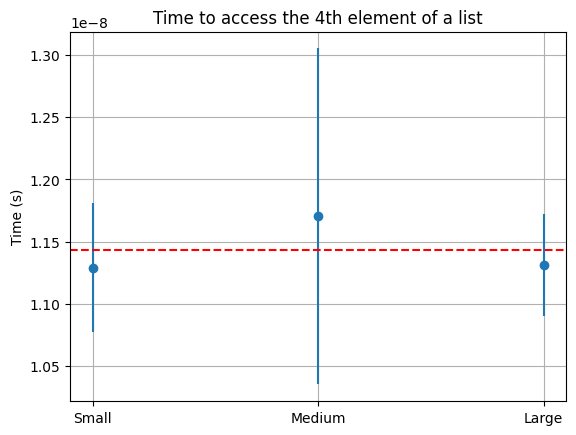

In [35]:
plt.errorbar([1, 4, 7], [small_mean, medium_mean, large_mean], yerr=[small_std, medium_std, large_std], fmt='o')
plt.axhline(y=mean_constant, color='r', linestyle='--', label='Mean time (constant)')
plt.xticks([1, 4, 7], ['Small', 'Medium', 'Large'])
plt.ylabel('Time (s)')
plt.title('Time to access the 4th element of a list')
plt.grid()
plt.show()

### $\mathcal{O}(\log n)$

Example: binary search in a sorted array.

In [41]:
def bin_search(lst: list[int], target: int) -> int:
    low = 0
    high = len(lst) - 1
    while low <= high:
        mid = (low + high) // 2
        if lst[mid] == target:
            return mid
        elif lst[mid] < target:
            low = mid + 1
        else:
            high = mid - 1
    return -1

bin_search([2, 5, 6, 8, 9, 12, 12], 6)

2

In [61]:
def benchmark_bin_search(n: int) -> tuple[float, float]:
    lst = list(range(n))
    target = n - 1 # worst case scenario
    N_repeats = 200
    times = repeat("bin_search(lst, target)", globals={"bin_search": bin_search, "lst": lst, "target": target}, number=N_repeats, repeat=1000)
    mean_time = mean(times) / N_repeats
    std_time = stdev(times) / N_repeats
    return mean_time, std_time

In [63]:
n_values = np.linspace(10**2, 10**5, 200, dtype=int)
benchmark_res = [benchmark_bin_search(n) for n in n_values]
mean_values, std_values = zip(*benchmark_res)

In [64]:
# fit to a logarithmic curve
def log_curve(x: float, a: float, b: float, c: float):
    return a * np.log(b * x) + c

params, _ = opt.curve_fit(log_curve, n_values, mean_values)

C:\Users\avaliullin\AppData\Local\Temp\ipykernel_15784\3267777355.py:3: RuntimeWarning: invalid value encountered in log
  return a * np.log(b * x) + c


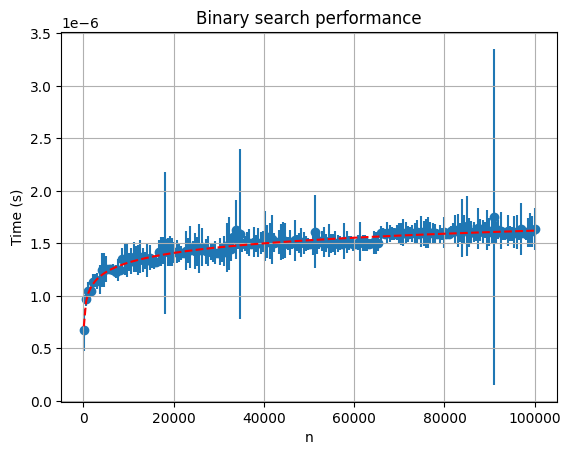

In [67]:
plt.plot(n_values, log_curve(np.array(n_values), *params), color='r', linestyle='--', zorder=2)
plt.errorbar(n_values, mean_values, yerr=std_values, fmt='o', zorder=1)
plt.xlabel('n')
plt.ylabel('Time (s)')
plt.title('Binary search performance')
plt.grid()
plt.show()

In [74]:
my_n = 10000
print(f'Binary search time complexity for n = {my_n}: {log_curve(my_n, *params):e} s')

Binary search time complexity for n = 10000: 1.317104e-06 s


### $\mathcal{O}(n)$

Example: sum of elements in an array.